# 02 Exploratory Data Analysis and Visualization

In this notebook we perform exploratory data analysis (EDA) on the Reuter_50_50 dataset.

The goal of this stage is to better understand the structure of the dataset before applying machine learning models.

The analysis includes:

- examining the distribution of documents across authors,
- analyzing document lengths,
- identifying frequently used words,
- visualizing text data using dimensionality reduction techniques.

Visualization of high-dimensional data in 2D space (using methods such as PCA and t-SNE) helps us gain intuition about how well documents from different authors can be separated based on their textual characteristics.

In [1]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from pathlib import Path

sns.set_style("whitegrid")

In [2]:
DATA_PATH = Path("../processed/reuters_raw_documents.csv")

df = pd.read_csv(DATA_PATH)

print("Dataset shape:", df.shape)

df.head()

Dataset shape: (5000, 6)


,file_name,author,split,text,text_length,word_count
0,106247newsML.txt,AaronPressman,train,The Internet may be overflowing with new techn...,2009,319
1,120600newsML.txt,AaronPressman,train,The U.S. Postal Service announced Wednesday a ...,2604,416
2,120683newsML.txt,AaronPressman,train,Elementary school students with access to the ...,491,72
3,136958newsML.txt,AaronPressman,train,An influential Internet organisation has backe...,2907,463
4,137498newsML.txt,AaronPressman,train,An influential Internet organisation has backe...,2299,356


In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5000 entries, 0 to 4999
Data columns (total 6 columns):
 #   Column       Non-Null Count  Dtype 
---  ------       --------------  ----- 
 0   file_name    5000 non-null   object
 1   author       5000 non-null   object
 2   split        5000 non-null   object
 3   text         5000 non-null   object
 4   text_length  5000 non-null   int64 
 5   word_count   5000 non-null   int64 
dtypes: int64(2), object(4)
memory usage: 234.5+ KB


In [4]:
df["author"].nunique()

50

In [5]:
docs_per_author = df["author"].value_counts()

docs_per_author.describe()

count     50.0
mean     100.0
std        0.0
min      100.0
25%      100.0
50%      100.0
75%      100.0
max      100.0
Name: count, dtype: float64

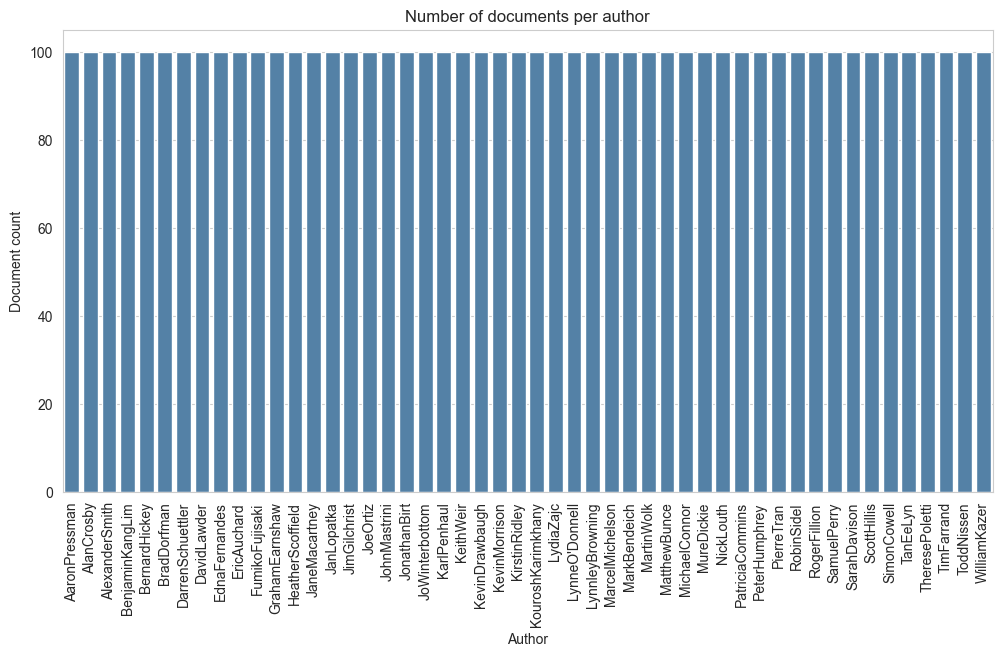

In [6]:
plt.figure(figsize=(12,6))

sns.barplot(
    x=docs_per_author.index,
    y=docs_per_author.values,
    color="steelblue"
)

plt.xticks(rotation=90)
plt.title("Number of documents per author")
plt.xlabel("Author")
plt.ylabel("Document count")

plt.show()

## Distribution of documents per author

Understanding how documents are distributed across authors is important for classification tasks.

The analysis shows that the dataset contains **50 authors**, each contributing exactly **100 documents**. This means that the dataset is **perfectly balanced across classes**.

Balanced datasets are highly desirable in machine learning because they prevent models from becoming biased toward certain classes.

Since each author has the same number of documents, classification algorithms will learn to distinguish authors based on their writing style rather than differences in dataset size.

## Class balance verification

The bar chart above shows the number of documents written by each author in the dataset.

Each of the 50 authors contributes exactly **100 documents**, which confirms that the dataset is **perfectly balanced across classes**.

The descriptive statistics further confirm this observation:

- minimum documents per author: **100**
- maximum documents per author: **100**
- standard deviation: **0**

A perfectly balanced dataset is particularly beneficial for classification tasks because it ensures that machine learning models will not become biased toward certain classes. Instead, the models will learn to distinguish authors based on their writing style rather than differences in dataset size.

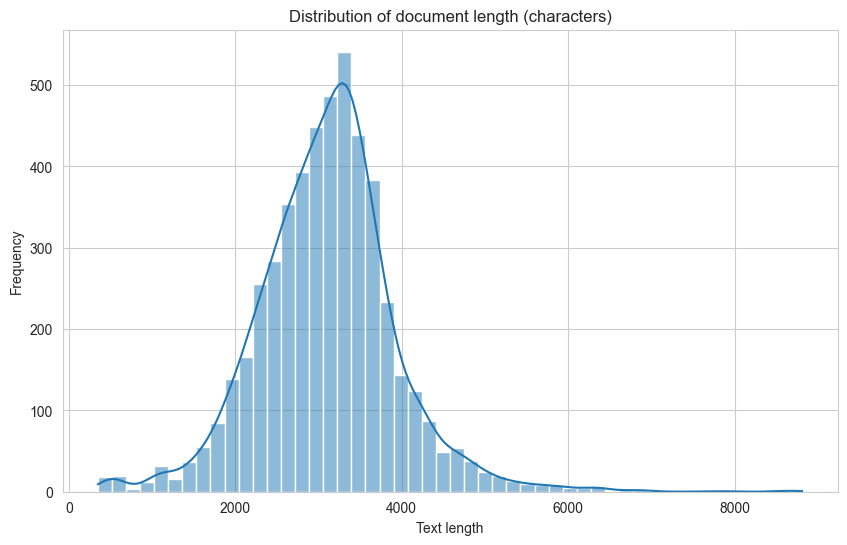

In [7]:
plt.figure(figsize=(10,6))

sns.histplot(df["text_length"], bins=50, kde=True)

plt.title("Distribution of document length (characters)")
plt.xlabel("Text length")
plt.ylabel("Frequency")

plt.show()

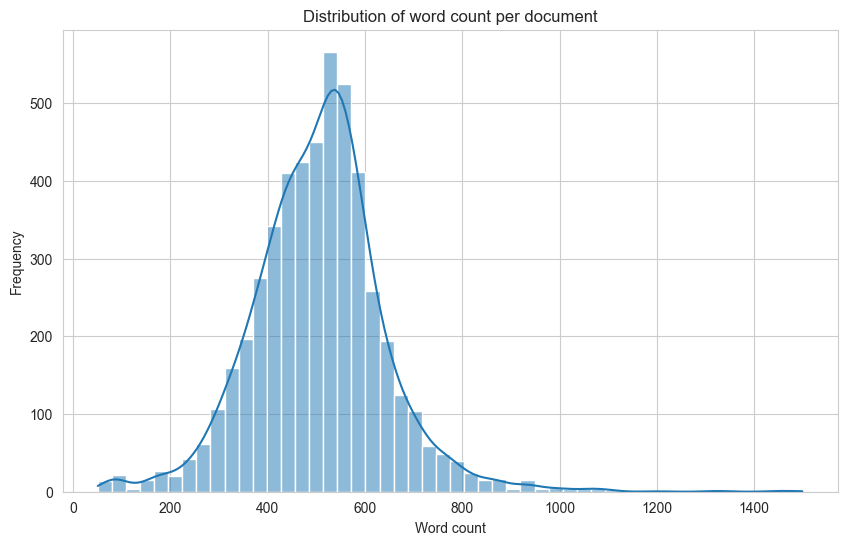

In [8]:
plt.figure(figsize=(10,6))

sns.histplot(df["word_count"], bins=50, kde=True)

plt.title("Distribution of word count per document")
plt.xlabel("Word count")
plt.ylabel("Frequency")

plt.show()

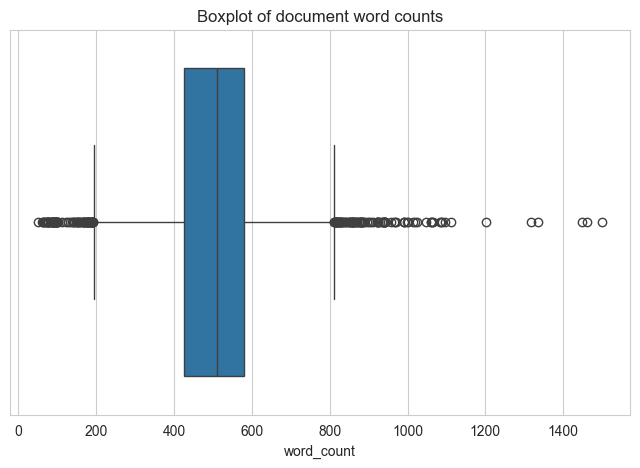

In [9]:
plt.figure(figsize=(8,5))

sns.boxplot(x=df["word_count"])

plt.title("Boxplot of document word counts")

plt.show()

## Document length distribution

To better understand the structure of the dataset, we analyze the distribution of document lengths.

Two measures are considered:

- the total number of characters in each document
- the number of words in each document

The histograms show that most documents fall within a relatively narrow range of lengths, indicating that the dataset contains news articles of comparable size.

The boxplot confirms that the majority of documents have similar word counts, with only a small number of longer documents appearing as outliers.

This consistency in document length is beneficial for text mining tasks because extremely short or extremely long documents can negatively influence feature extraction methods such as Bag-of-Words or TF-IDF.

## Document length distribution

The histograms illustrate the distribution of document lengths in the dataset.

The character-length distribution shows a roughly **bell-shaped (approximately normal) distribution**, with most documents centered around **3000–3300 characters**. A small right tail indicates the presence of longer articles.

The word-count distribution reveals that most documents contain approximately **500–550 words**, with the majority of documents falling between **400 and 600 words**.

The boxplot confirms these observations. The median document length is around **500 words**, and the interquartile range spans roughly **430 to 580 words**. While several longer documents appear as outliers, they are relatively rare and do not dominate the dataset.

Overall, the dataset consists of **moderately sized news articles with relatively consistent lengths**, which is advantageous for text mining and machine learning tasks because it reduces bias caused by extreme document sizes.

In [10]:
all_text = " ".join(df["text"])

In [11]:
words = all_text.lower().split()

len(words)

2528302

In [12]:
from collections import Counter

word_freq = Counter(words)

word_freq.most_common(20)

[('the', 139729),
 ('to', 73158),
 ('of', 68047),
 ('a', 56469),
 ('in', 55169),
 ('and', 51834),
 ('said', 26263),
 ('on', 24467),
 ('for', 24133),
 ('that', 20470),
 ('is', 19441),
 ('with', 15549),
 ('it', 15449),
 ('be', 14658),
 ('by', 14453),
 ('its', 14156),
 ('at', 13686),
 ('was', 13569),
 ('as', 13354),
 ('from', 12394)]

## Word frequency analysis

To better understand the textual characteristics of the dataset, we analyzed the frequency of individual words across all documents.

After combining all text documents and tokenizing them into words, the dataset contains approximately **2.5 million word tokens**.

The most frequent words include:

- the
- to
- of
- a
- in
- and

These words are commonly referred to as **stopwords**. They are grammatical words that occur very frequently in natural language but usually carry little semantic meaning.

Because of their high frequency and limited informational value, stopwords are typically removed during text preprocessing when building machine learning models. Removing them helps focus the analysis on more informative terms that better capture differences between documents.

This observation confirms that the dataset behaves as expected for natural language text and motivates the preprocessing steps that will be applied in later stages of the project.

In [13]:
top_words = pd.DataFrame(word_freq.most_common(20), columns=["word", "count"])

top_words

,word,count
0,the,139729
1,to,73158
2,of,68047
3,a,56469
4,in,55169
5,and,51834
6,said,26263
7,on,24467
8,for,24133
9,that,20470


C:\Users\Dell\AppData\Local\Temp\ipykernel_6964\3793694684.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


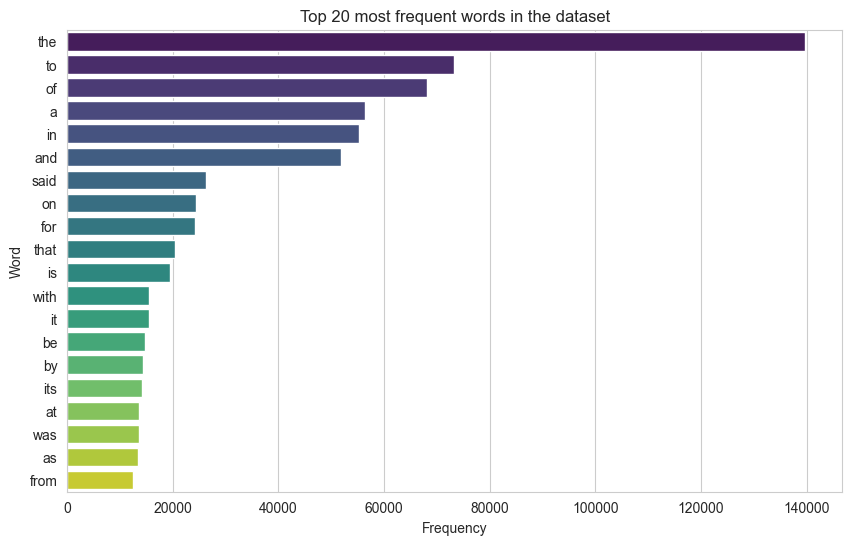

In [14]:
plt.figure(figsize=(10,6))

sns.barplot(
    data=top_words,
    x="count",
    y="word",
    palette="viridis"
)

plt.title("Top 20 most frequent words in the dataset")

plt.xlabel("Frequency")
plt.ylabel("Word")

plt.show()

## Most frequent words in the dataset

The bar chart above illustrates the most frequent words appearing across all documents in the dataset.

As expected, the most frequent terms are common English stopwords such as **"the", "to", "of", "and", "in"**, which appear extremely often in natural language text.

These words dominate the frequency distribution because they serve grammatical rather than semantic roles. While they are essential for sentence structure, they provide limited information about the topic or writing style of a document.

For this reason, stopwords are commonly removed during the preprocessing stage of text mining workflows. Removing them allows machine learning models to focus on more informative words that help distinguish documents and authors.

In [15]:
from sklearn.feature_extraction.text import TfidfVectorizer

tfidf = TfidfVectorizer(
    stop_words="english",
    max_features=3000
)

X = tfidf.fit_transform(df["text"])

print("TF-IDF matrix shape:", X.shape)

TF-IDF matrix shape: (5000, 3000)


In [16]:
from sklearn.decomposition import PCA

pca = PCA(n_components=2)

X_dense = X.toarray()

X_pca = pca.fit_transform(X_dense)

print("PCA shape:", X_pca.shape)

PCA shape: (5000, 2)


In [17]:
pca_df = pd.DataFrame({
    "PC1": X_pca[:,0],
    "PC2": X_pca[:,1],
    "author": df["author"]
})

pca_df.head()

,PC1,PC2,author
0,-0.032229,-0.113971,AaronPressman
1,-0.015661,-0.109157,AaronPressman
2,-0.004231,-0.098513,AaronPressman
3,0.002451,-0.109270,AaronPressman
4,-0.004180,-0.119472,AaronPressman


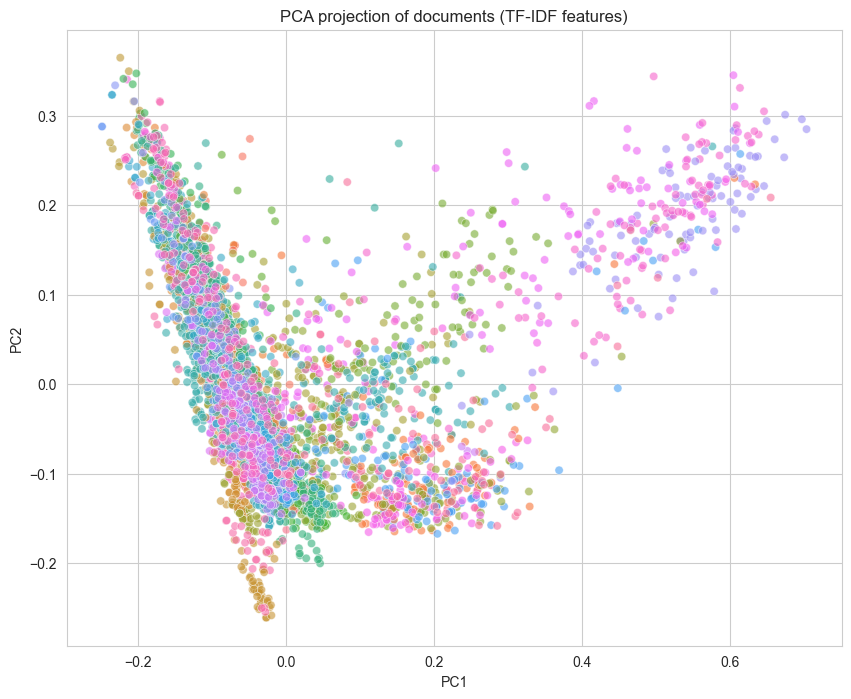

In [18]:
plt.figure(figsize=(10,8))

sns.scatterplot(
    data=pca_df,
    x="PC1",
    y="PC2",
    hue="author",
    legend=False,
    alpha=0.6
)

plt.title("PCA projection of documents (TF-IDF features)")

plt.show()

## PCA visualization of TF-IDF features

Text data is inherently high-dimensional because each unique word can represent a separate feature.

To visualize the dataset in two dimensions, we first transformed the documents into numerical vectors using **TF-IDF (Term Frequency–Inverse Document Frequency)**. This representation captures the importance of words within documents while reducing the influence of very common terms.

The resulting TF-IDF matrix contains thousands of features. To make visualization possible, we applied **Principal Component Analysis (PCA)** to reduce the dimensionality to two components.

The scatter plot above shows the documents projected onto the first two principal components. Each point represents one document.

Although the documents form a large cloud rather than clearly separated clusters, this is expected for authorship datasets where stylistic differences between authors can be subtle.

Nevertheless, this visualization provides insight into the structure of the dataset and demonstrates how high-dimensional textual data can be projected into a lower-dimensional space for exploratory analysis.

## PCA projection of TF-IDF document vectors

To visualize the structure of the dataset, we transformed the text documents into numerical vectors using **TF-IDF** with a maximum of 3000 features.

The resulting TF-IDF matrix has the following shape:

- **5000 documents**
- **3000 features**

Since this representation is high-dimensional, we applied **Principal Component Analysis (PCA)** to reduce the dimensionality to two components.

The scatter plot above shows the projection of the documents onto the first two principal components.

The visualization reveals that the documents form a large continuous cloud rather than clearly separated clusters. This behavior is expected because:

- the dataset contains **50 different authors**,  
- many authors write about **similar topics**,  
- stylistic differences between authors are often subtle.

Additionally, PCA is a **linear dimensionality reduction method**, which may not fully capture the complex relationships present in high-dimensional textual data.

Nevertheless, this visualization provides a useful overview of the global structure of the dataset and demonstrates how high-dimensional text representations can be projected into a two-dimensional space.

In [19]:
from sklearn.manifold import TSNE

tsne = TSNE(
    n_components=2,
    perplexity=30,
    random_state=42,
    n_iter=1000
)

X_tsne = tsne.fit_transform(X.toarray())

print(X_tsne.shape)

C:\Users\Dell\AppData\Local\Programs\Python\Python311\Lib\site-packages\sklearn\manifold\_t_sne.py:1164: FutureWarning: 'n_iter' was renamed to 'max_iter' in version 1.5 and will be removed in 1.7.
  warnings.warn(


(5000, 2)


In [20]:
tsne_df = pd.DataFrame({
    "TSNE1": X_tsne[:,0],
    "TSNE2": X_tsne[:,1],
    "author": df["author"]
})

tsne_df.head()

,TSNE1,TSNE2,author
0,-52.037518,41.148010,AaronPressman
1,-58.068993,40.627590,AaronPressman
2,-48.017067,44.516708,AaronPressman
3,-54.398594,44.713577,AaronPressman
4,-54.384605,44.722515,AaronPressman


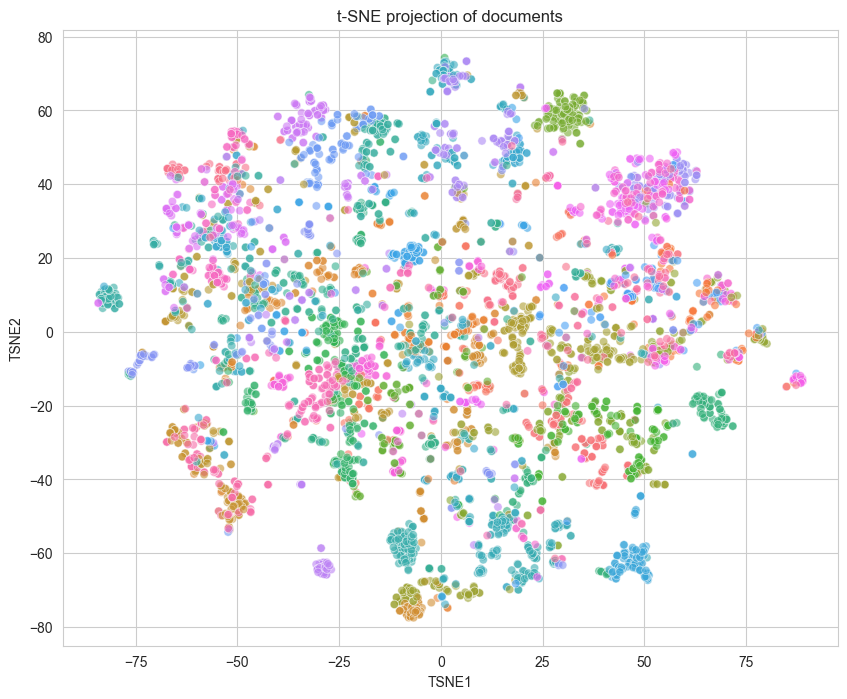

In [21]:
plt.figure(figsize=(10,8))

sns.scatterplot(
    data=tsne_df,
    x="TSNE1",
    y="TSNE2",
    hue="author",
    legend=False,
    alpha=0.6
)

plt.title("t-SNE projection of documents")

plt.show()

## t-SNE visualization of document representations

To further explore the structure of the dataset, we applied **t-distributed Stochastic Neighbor Embedding (t-SNE)** to the TF-IDF document vectors.

Unlike PCA, which is a linear dimensionality reduction technique, t-SNE is a **nonlinear method** that is particularly effective at preserving local relationships between data points.

The visualization shows the documents projected into a two-dimensional space. Each point represents a single document, and the colors correspond to different authors.

Compared to the PCA projection, the t-SNE visualization reveals **more localized clusters of documents**. Many documents written by the same author appear close to each other, suggesting that the TF-IDF representation captures stylistic patterns characteristic of individual writers.

Although the clusters are not perfectly separated, which is expected given the similarity of topics in news articles, the visualization indicates that meaningful structure exists in the data. This suggests that machine learning models should be able to learn patterns that help distinguish between authors.

Overall, the t-SNE projection provides an intuitive view of the high-dimensional text data and demonstrates the presence of latent structure in the dataset.

## Summary of exploratory data analysis

In this notebook we explored the structure of the Reuter_50_50 dataset before applying machine learning models.

The key findings of the exploratory analysis are:

- The dataset contains **5000 documents written by 50 different authors**.
- Each author contributes **100 documents**, making the dataset perfectly balanced.
- Most documents contain approximately **500 words** and around **3000 characters**, indicating relatively consistent article lengths.
- The most frequent words are common English stopwords, which confirms the need for stopword removal during preprocessing.
- Dimensionality reduction techniques (PCA and t-SNE) reveal that documents form structured regions in the feature space.

The PCA visualization shows the global structure of the dataset, while the t-SNE projection highlights local clusters of documents, suggesting that stylistic differences between authors exist in the TF-IDF representation.

These observations confirm that the dataset is suitable for **authorship classification tasks** and provide motivation for the preprocessing and modeling steps that follow.